# Project Evals — Continue / Schedule / End

Use the **OpenAI Evals API** to test how well a prompted model classifies the next recruiter action on our labeled `sms_conversations.json` data.

This mirrors **Part A** of the class notebook, but the task is our project's task (not e-commerce complaints).

At the end there is also a **bonus section** that evaluates our actual multi-agent system (`get_main_agent_response`) locally.

## Setup

### Install dependencies (run once)
```powershell
pip install openai python-dotenv scikit-learn pandas matplotlib seaborn
```

In [9]:
# Import the OpenAI client, the dotenv loader, and os for environment variables.
from openai import OpenAI
from dotenv import load_dotenv
import os

In [10]:
# Load environment variables from .env and read the OpenAI API key.
# Print only the first few characters to confirm it loaded (never the full key).

load_dotenv()  # Loads variables from .env

openai_key = os.getenv("OPENAI_API_KEY")
print(openai_key[:5])  # Just to check, don't print the full key!

sk-pr


In [11]:
# Initialize the OpenAI client (reads OPENAI_API_KEY from the environment).
client = OpenAI()

## (Optional) Reset the OpenAI account

⚠️ **Destructive.** The cells below permanently delete **every file,
eval, and fine-tuned model** on your OpenAI account. They exist so you can
start fresh between experiments. They are **not** part of the normal flow -
run them only when you explicitly want to clean up.

In [ ]:
# Delete ALL uploaded files on the OpenAI account.
for f in client.files.list().data:
    try:
        client.files.delete(f.id)
        print(f"deleted file {f.id} ({f.filename})")
    except Exception as e:
        print(f"could not delete file {f.id}: {e}")

In [ ]:
# Delete ALL evals (this also removes their runs).
for ev in client.evals.list().data:
    try:
        client.evals.delete(ev.id)
        print(f"deleted eval {ev.id} ({ev.name})")
    except Exception as e:
        print(f"could not delete eval {ev.id}: {e}")

In [ ]:
# Fine-tuning cleanup. NOTE: the API has no "delete fine-tuning job" - you
# can only CANCEL jobs that are still running and DELETE the fine-tuned
# models they produced. This cell does both.

# 1) Cancel any job that is not in a terminal state.
for job in client.fine_tuning.jobs.list().data:
    if job.status in ("validating_files", "queued", "running"):
        try:
            client.fine_tuning.jobs.cancel(job.id)
            print(f"cancelled job {job.id}")
        except Exception as e:
            print(f"could not cancel job {job.id}: {e}")

# 2) Delete every fine-tuned model (ids that start with "ft:").
for m in client.models.list().data:
    if m.id.startswith("ft:"):
        try:
            client.models.delete(m.id)
            print(f"deleted model {m.id}")
        except Exception as e:
            print(f"could not delete model {m.id}: {e}")

## Prepare the test data

Convert `Relevant Files/sms_conversations.json` into a **JSONL** file where each line is one test item. We classify the next recruiter action given the conversation so far.

Each line will look like:
```json
{ "item": { "conversation_history": "recruiter: ...\ncandidate: ...", "correct_label": "continue" } }
```

In [12]:
# Load the labeled SMS conversations dataset into a list of conversation dicts.
import json

# Open and load the conversations JSON file:
with open("../Relevant Files/sms_conversations.json", encoding="utf-8") as conversations_file:
    conversations = json.load(conversations_file)

print(json.dumps(conversations[0], indent=4))

{
    "conversation_id": 1,
    "candidate_phone": "+1-555-0201",
    "recruiter_phone": "+1-555-0000",
    "start_time_utc": "2024-04-03T15:12:00Z",
    "turns": [
        {
            "turn_id": 1,
            "speaker": "recruiter",
            "timestamp_utc": "2024-04-03T15:12:00Z",
            "text": "Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?",
            "label": "continue"
        },
        {
            "turn_id": 2,
            "speaker": "candidate",
            "timestamp_utc": "2024-04-03T15:13:19Z",
            "text": "I've been using Python professionally for five years, mostly for data analysis.",
            "label": null
        },
        {
            "turn_id": 3,
            "speaker": "recruiter",
            "timestamp_utc": "2024-04-03T15:15:01Z",
            "text": "Our engineering manager can interview you Wednesday at 10\u202fAM or Thursday at 2\u202fPM. Which works best?",
         

In [13]:
# Helper that turns a list of conversation turns into a single readable string,
# one "speaker: text" line per turn. Used to build each test case's history.

def format_history(turns):
    return "\n".join(
        f"{turn['speaker']}: {turn['text']}"
        for turn in turns
        )

In [14]:
print(format_history(conversations[0]["turns"]))

recruiter: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?
candidate: I've been using Python professionally for five years, mostly for data analysis.
recruiter: Our engineering manager can interview you Wednesday at 10 AM or Thursday at 2 PM. Which works best?
candidate: I can't at that time—I'm busy.
recruiter: No problem. How about Thursday at 4 PM instead?
candidate: Monday at 3 PM is good.
recruiter: Great, your interview is confirmed. You'll receive a calendar invite shortly.


In [15]:
# Build the list of test cases: for every labeled recruiter turn, pair the
# conversation history up to that point with the correct next-action label.
# Candidate turns have label=None and are skipped.

test_items = []

for conversation in conversations:
    turns = conversation["turns"]

    for turn_index, turn in enumerate(turns):
        speaker = turn["speaker"]
        label = turn["label"] # Not null if recruiter

        if speaker == "recruiter" and label is not None:
            prior_turns = turns[:turn_index] # Everything BEFORE this turn
            history = format_history(prior_turns)
            test_items.append({'conversation_history': history, 'correct_label': label}) 


In [16]:
# Write the test cases to JSONL, one {"item": {...}} object per line
# (the format the OpenAI Evals API expects).

with open("sms_conversations_test.jsonl", "w" , encoding="utf-8") as test_file:
    for item in test_items:
        json.dump({"item": item}, test_file)
        test_file.write("\n")

## Define the task

The instructions tell the model what to output. We want a single word: `continue`, `schedule`, or `end`.

In [17]:
# System prompt: instruct the model to classify the next recruiter action
# as exactly one of 'continue', 'schedule', or 'end' and reply with only that word.
instructions = """
You are a classifier that labels the next recruiter action in an SMS recruitment
chatbot for a Python Developer position.

Given a conversation history between a recruiter and a candidate, decide what the
recruiter should do NEXT, and output exactly one of three labels:

    continue  — Keep the conversation going. Use when the candidate is still sharing
                background, asking questions about the role, or the conversation is
                in its early stages and there is not yet enough context to schedule
                an interview. Also use when the candidate cannot make a proposed
                time slot and an alternative is needed but none has been offered yet.

    schedule  — The recruiter should propose, validate, or confirm an interview slot.
                Use when the candidate has shown interest and shared enough background,
                the candidate brings up availability or specific dates, the recruiter
                is offering time slots, or an interview is being confirmed.

    end       — The conversation should be closed. Use when the candidate explicitly
                declines (not interested, already found a job, asks to stop), or when
                an interview has just been confirmed and there is nothing left to
                discuss.

OUTPUT RULES (strict — your output is graded by exact string match):
 - Reply with EXACTLY one word: continue, schedule, or end.
 - Lowercase only.
 - No punctuation, no quotes, no explanation, no whitespace before or after.

EXAMPLES:

  History:
  recruiter: Thanks for applying to our Python Developer opening. Could you tell me about your recent Python work?
  candidate: I've been using Python professionally for five years, mostly for data analysis and building internal
  tools.
  Answer: continue

  History:
  recruiter: Thanks for sharing your background — sounds like a great fit.
  candidate: Thanks! When would the interview be?
  Answer: schedule

  History:
  recruiter: Would you be available for an interview next week?
  candidate: Actually, I just accepted another offer last week, so I have to withdraw. Thanks anyway.
  Answer: end

Now classify the following conversation. Remember: reply with only one word.
"""

In [18]:
test_items[2]

{'conversation_history': "recruiter: Thanks for applying to our Python Developer opening. What kinds of Python projects have you worked on recently?\ncandidate: I've been using Python professionally for five years, mostly for data analysis.\nrecruiter: Our engineering manager can interview you Wednesday at 10\u202fAM or Thursday at 2\u202fPM. Which works best?\ncandidate: I can't at that time—I'm busy.",
 'correct_label': 'schedule'}

In [19]:
# Quick sanity check: run one sample conversation through the model
# and print its reply to verify it returns one of the three labels.

completion = client.chat.completions.create(
    model="gpt-4.1",
    messages=[
        {"role": "developer", "content": instructions},
        {"role": "user", "content": test_items[2]["conversation_history"]}
    ]
)

print(completion.choices[0].message.content)

continue


## Create the eval

An eval = a **data schema** (`data_source_config`) + **graders** (`testing_criteria`). We use a `string_check` grader with `eq` to compare the model output to `correct_label`.

In [20]:
# Create the eval: define the data schema (conversation_history + correct_label)
# and a string_check grader that compares the model output to the correct label.

eval_obj = client.evals.create(
    name = "Recruiter Action Routing",

    data_source_config={
        "type": "custom",
        "item_schema": {
            "type": "object",
            "properties": {
                "conversation_history": {"type": "string"},
                "correct_label": {"type": "string"},
            },
            "required": ["conversation_history", "correct_label"],
        },
        "include_sample_schema": True
    },
    testing_criteria=[
        {
            "type": "string_check",
            "name": "Match output to human label",
            "input": "{{ sample.output_text }}",
            "operation": "eq",
            "reference": "{{ item.correct_label }}"
        }
    ],
)

print(eval_obj)
print(eval_obj.id)

EvalCreateResponse(id='eval_6a0acf58e588819196a1a8ef6593cab8', created_at=1779093336, data_source_config=EvalCustomDataSourceConfig(schema_={'type': 'object', 'properties': {'item': {'type': 'object', 'properties': {'conversation_history': {'type': 'string'}, 'correct_label': {'type': 'string'}}, 'required': ['conversation_history', 'correct_label']}, 'sample': {'type': 'object', 'properties': {'model': {'type': 'string'}, 'choices': {'type': 'array', 'items': {'type': 'object', 'properties': {'message': {'type': 'object', 'properties': {'role': {'type': 'string', 'enum': ['assistant']}, 'content': {'type': ['string', 'array', 'null']}, 'refusal': {'type': ['boolean', 'null']}, 'tool_calls': {'type': ['array', 'null'], 'items': {'type': 'object', 'properties': {'type': {'type': 'string', 'enum': ['function']}, 'function': {'type': 'object', 'properties': {'name': {'type': 'string'}, 'arguments': {'type': 'string'}}, 'required': ['name', 'arguments']}, 'id': {'type': 'string'}}, 'requir

## Upload the test JSONL

In [21]:
# Upload the test JSONL file to OpenAI so the eval run can read it.

file = client.files.create(
    file=open("sms_conversations_test.jsonl", "rb"),
    purpose="evals"
)

print(file)
print(file.id)

FileObject(id='file-PTseNDXUW5ztdhJbYbiRqS', bytes=20195, created_at=1779093339, filename='sms_conversations_test.jsonl', object='file', purpose='evals', status='processed', expires_at=None, status_details=None)
file-PTseNDXUW5ztdhJbYbiRqS


## Create the eval run

In [22]:
# Create the eval run: use gpt-4.1 with our instructions as the system prompt
# and the uploaded JSONL as the data source.

run = client.evals.runs.create(
    eval_obj.id, 

    name= "Recruiter text run",

    data_source={
        "type": "completions",
        "model": "gpt-4.1",
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "developer", "content": instructions},
                {"role": "user", "content": "{{ item.conversation_history }}"}
            ],
        },
        "source": {"type": "file_id", "id": file.id},
    },
)

print(run)
print(run.id)

RunCreateResponse(id='evalrun_6a0acf622de88191aceaf2d8ce46b51e', created_at=1779093346, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileID(id='file-PTseNDXUW5ztdhJbYbiRqS', type='file_id'), type='completions', input_messages=InputMessagesTemplate(template=[EasyInputMessage(content="\nYou are a classifier that labels the next recruiter action in an SMS recruitment\nchatbot for a Python Developer position.\n\nGiven a conversation history between a recruiter and a candidate, decide what the\nrecruiter should do NEXT, and output exactly one of three labels:\n\n    continue  — Keep the conversation going. Use when the candidate is still sharing\n                background, asking questions about the role, or the conversation is\n                in its early stages and there is not yet enough context to schedule\n                an interview. Also use when the candidate cannot make a proposed\n                time slot and an alternative is needed but none has been offered ye

## Analyze the results

In [24]:
# Retrieve the run and print its status (wait until it becomes 'completed').
run_retrieve = client.evals.runs.retrieve(
    eval_id=eval_obj.id, # YOUR_EVAL_ID
    run_id=run.id # YOUR_RUN_ID
    )


print(run_retrieve)
print(run_retrieve.status)

RunRetrieveResponse(id='evalrun_6a0acf622de88191aceaf2d8ce46b51e', created_at=1779093346, data_source=CreateEvalCompletionsRunDataSource(source=SourceFileID(id='file-PTseNDXUW5ztdhJbYbiRqS', type='file_id'), type='completions', input_messages=InputMessagesTemplate(template=[EasyInputMessage(content="\nYou are a classifier that labels the next recruiter action in an SMS recruitment\nchatbot for a Python Developer position.\n\nGiven a conversation history between a recruiter and a candidate, decide what the\nrecruiter should do NEXT, and output exactly one of three labels:\n\n    continue  — Keep the conversation going. Use when the candidate is still sharing\n                background, asking questions about the role, or the conversation is\n                in its early stages and there is not yet enough context to schedule\n                an interview. Also use when the candidate cannot make a proposed\n                time slot and an alternative is needed but none has been offered 

In [25]:
# Print the pass / fail tallies from the completed run.
print(f"Errored = {run_retrieve.result_counts.errored}")
print(f"Total = {run_retrieve.result_counts.total}")
print(f"Passed = {run_retrieve.result_counts.passed}")
print(f"Failed = {run_retrieve.result_counts.failed}")

Errored = 0
Total = 59
Passed = 32
Failed = 27


In [26]:
# Fetch the per-item results: true labels come from the dataset,
# predicted labels come from the model's output (stripped of whitespace).

items = client.evals.runs.output_items.list(
    eval_id=eval_obj.id,
    run_id=run.id
)

y_true = [item.datasource_item['correct_label'] for item in items]
y_pred = [item.sample.output[0].content.strip() for item in items]

print(y_true)
print(y_pred)

['end', 'continue', 'continue', 'end', 'schedule', 'continue', 'end', 'schedule', 'schedule', 'continue', 'end', 'continue', 'schedule', 'continue', 'schedule', 'end', 'schedule', 'continue', 'continue', 'schedule', 'continue', 'continue', 'schedule', 'schedule', 'schedule', 'schedule', 'continue', 'continue', 'continue', 'end', 'end', 'continue', 'schedule', 'end', 'continue', 'schedule', 'continue', 'continue', 'end', 'continue', 'end', 'continue', 'schedule', 'end', 'end', 'schedule', 'continue', 'schedule', 'end', 'continue', 'schedule', 'end', 'continue', 'schedule', 'continue', 'continue', 'continue', 'schedule', 'end']
['schedule', 'continue', 'continue', 'end', 'continue', 'continue', 'schedule', 'continue', 'continue', 'continue', 'end', 'continue', 'continue', 'continue', 'continue', 'end', 'continue', 'continue', 'continue', 'continue', 'continue', 'continue', 'continue', 'continue', 'continue', 'continue', 'continue', 'continue', 'continue', 'end', 'schedule', 'continue', '

In [27]:
# Compute and print the model's overall accuracy against the human labels.
from sklearn.metrics import accuracy_score

print(f"accuracy_score: {accuracy_score(y_true, y_pred)}")

accuracy_score: 0.5423728813559322


In [28]:
# Union of all seen labels, sorted:
labels = sorted(set(y_true) | set(y_pred))
print(labels)

['continue', 'end', 'schedule']


In [29]:
# Build the confusion matrix and display it as a labeled pandas DataFrame.
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_true, y_pred, labels=labels)

df_cm = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion Matrix:\n")
print(df_cm)

Confusion Matrix:

          continue  end  schedule
continue        25    0         0
end              0    6         9
schedule        17    1         1


In [30]:
import numpy as np

for idx, label in enumerate(labels):
    TP = cm[idx, idx]
    FP = cm[:, idx].sum() - TP
    FN = cm[idx, :].sum() - TP
    TN = cm.sum() - (TP + FP + FN)
    print(f"\nLabel: {label}")
    print(f"  TP: {TP}")
    print(f"  FP: {FP}")
    print(f"  FN: {FN}")
    print(f"  TN: {TN}")


Label: continue
  TP: 25
  FP: 17
  FN: 0
  TN: 17

Label: end
  TP: 6
  FP: 1
  FN: 9
  TN: 43

Label: schedule
  TP: 1
  FP: 9
  FN: 18
  TN: 31


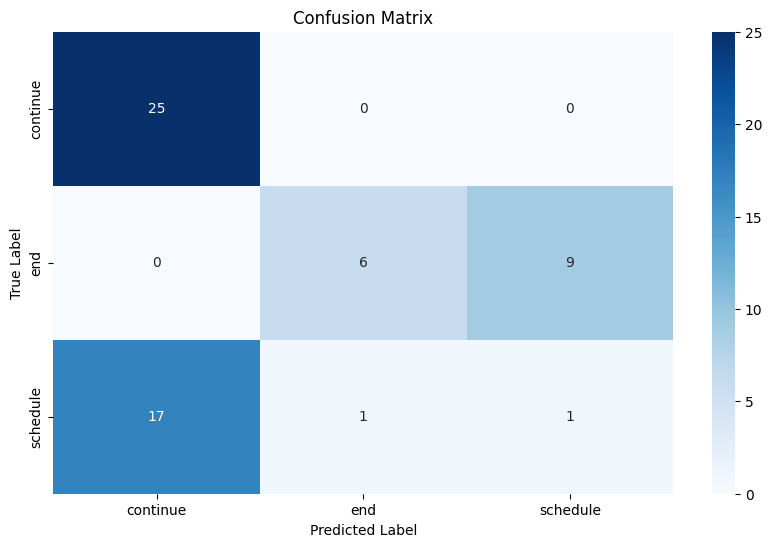

In [31]:
# Plot the confusion matrix as a heatmap.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

---

## Bonus: Evaluate our actual multi-agent system

The cells above test a **single prompt** against `gpt-4.1` through OpenAI's cloud eval. That is useful as a baseline, but it doesn't test the code we actually wrote.

Below we run the **same test cases** through our real pipeline — `get_main_agent_response` — which routes through the Exit / Scheduling / Info advisors. Then we compute Accuracy + Confusion Matrix the same way.

In [32]:
# Add the project root to sys.path so the `app` package is importable here.
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))   # adds the project root to sys.path

In [33]:
# Import the LangChain LLM wrapper and our real multi-agent entry point.
from langchain_openai import ChatOpenAI
from app.modules.agents.main_agent import get_main_agent_response

In [34]:
# Create the LLM our multi-agent system will use (deterministic: temperature=0).
llm = ChatOpenAI(model="gpt-4.1", temperature=0)

In [35]:
# Run the same test cases through our real pipeline (get_main_agent_response),
# collecting the predicted action and the corresponding correct label for each.

y_pred_local = []
y_true_local = []

for item in test_items:
    action = get_main_agent_response(item["conversation_history"], llm)["action"]
    y_pred_local.append(action)
    y_true_local.append(item['correct_label'])

In [36]:
print("y_pred_local")
print(y_pred_local)
print("\n")

print("y_true_local")
print(y_true_local)

y_pred_local
['continue', 'continue', 'schedule', 'schedule', 'continue', 'continue', 'continue', 'schedule', 'end', 'continue', 'continue', 'continue', 'schedule', 'continue', 'continue', 'continue', 'schedule', 'continue', 'continue', 'end', 'continue', 'continue', 'schedule', 'continue', 'continue', 'schedule', 'schedule', 'continue', 'continue', 'schedule', 'end', 'end', 'continue', 'continue', 'continue', 'end', 'continue', 'continue', 'continue', 'schedule', 'continue', 'continue', 'continue', 'schedule', 'schedule', 'continue', 'continue', 'schedule', 'schedule', 'continue', 'continue', 'end', 'continue', 'continue', 'schedule', 'schedule', 'continue', 'continue', 'end']


y_true_local
['continue', 'schedule', 'schedule', 'end', 'continue', 'continue', 'continue', 'schedule', 'end', 'continue', 'continue', 'continue', 'end', 'continue', 'continue', 'continue', 'end', 'continue', 'schedule', 'end', 'continue', 'schedule', 'end', 'continue', 'schedule', 'schedule', 'end', 'continu

In [37]:
# Print the multi-agent system's overall accuracy against the human labels.

from sklearn.metrics import accuracy_score

print(f"accuracy_score: {accuracy_score(y_true_local, y_pred_local)}")

accuracy_score: 0.6440677966101694


In [38]:
# Build the multi-agent system's confusion matrix and print it as a DataFrame.
from sklearn.metrics import confusion_matrix
import pandas as pd

labels = sorted(set(y_true_local) | set(y_pred_local))

cm = confusion_matrix(y_true_local, y_pred_local, labels=labels)

df_cm = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion Matrix:\n")
print(df_cm)


Confusion Matrix:

          continue  end  schedule
continue        25    0         0
end              0    6         9
schedule        11    1         7


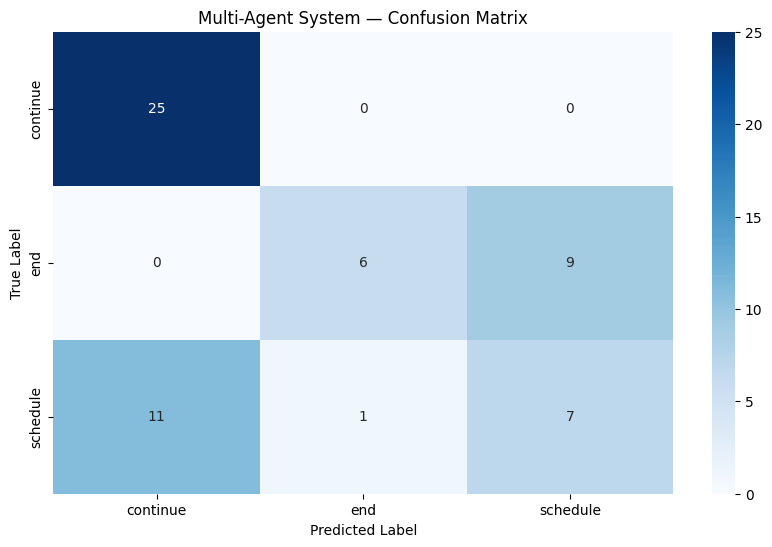

In [39]:
# Plot the multi-agent system's confusion matrix as a heatmap.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df_cm, annot=True, fmt='d', cmap="Blues")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Multi-Agent System — Confusion Matrix')
plt.show()

---

## Fine-Tuning — Recruiter Action Classifier

So far we tested a **prompted base model** and our **multi-agent system**.

Now we **fine-tune** a base model on our own training examples, then run the
**same eval** on it and compare the accuracy.

Workflow (mirrors **Part B** of the class notebook):
split data → build training JSONL → upload → create fine-tuning job →
get the fine-tuned model → evaluate.

In [ ]:
# Split the labeled data into a training set and a held-out evaluation set.
# We fine-tune ONLY on train_items and evaluate ONLY on eval_items, so the
# model is never tested on conversations it was trained on.
# random.seed makes the 80/20 split reproducible across runs.
import random

random.seed(42)

shuffled = test_items.copy()
random.shuffle(shuffled)

split_index = int(len(shuffled) * 0.8)          # 80% train / 20% eval
train_items = shuffled[:split_index]
eval_items = shuffled[split_index:]

print(f"train_items: {len(train_items)}")
print(f"eval_items:  {len(eval_items)}")

In [ ]:
# Convert each training example into OpenAI's chat fine-tuning format:
# one object per example with a system / user / assistant message triple.
#   system    = the same task instructions used everywhere else
#   user      = the conversation history
#   assistant = the correct label (what we want the model to learn to output)
training_examples = [
    {
        "messages": [
            {"role": "system", "content": instructions},
            {"role": "user", "content": item["conversation_history"]},
            {"role": "assistant", "content": item["correct_label"]},
        ]
    }
    for item in train_items
]

print(f"Built {len(training_examples)} training examples")
print(json.dumps(training_examples[0], indent=2, ensure_ascii=False))

In [ ]:
# Write the training examples to a JSONL file (one JSON object per line) -
# this is the file OpenAI reads to fine-tune the model.
with open("sms_conversations_training.jsonl", "w", encoding="utf-8") as f:
    for example in training_examples:
        json.dump(example, f)
        f.write("\n")

print("Wrote sms_conversations_training.jsonl")

In [ ]:
# Upload the training file to OpenAI with purpose="fine-tune".
# Stored as train_file (NOT `file`) so it never collides with the eval
# test-file upload from the eval section above.
train_file = client.files.create(
    file=open("sms_conversations_training.jsonl", "rb"),
    purpose="fine-tune",
)

print(train_file.id)

In [ ]:
# Start a Supervised Fine-Tuning (SFT) job on a base model using our
# training file. Training is not instant - it can take several minutes.
fine_tune = client.fine_tuning.jobs.create(
    model="gpt-4.1-2025-04-14",
    training_file=train_file.id,
    method={"type": "supervised"},
)

print(fine_tune)

In [ ]:
# Look up the job we just created. Once its status is "succeeded", read the
# fine_tuned_model id (the "ft:..." model we will evaluate). Matching on
# fine_tune.id guarantees we pick OUR job, not some older fine-tune.
from datetime import datetime

my_fine_tuned_model = None

for ft in client.fine_tuning.jobs.list().data:
    if ft.id == fine_tune.id and ft.status == "succeeded":
        my_fine_tuned_model = ft.fine_tuned_model
        print(f"Job {ft.id} succeeded")
        print(f"Base model:        {ft.model}")
        print(f"Fine-tuned model:  {ft.fine_tuned_model}")
        print(f"Finished at:       {datetime.fromtimestamp(ft.finished_at)}")
        break

if my_fine_tuned_model is None:
    print(f"Job {fine_tune.id} has not finished yet - re-run this cell later.")

In [ ]:
# Quick sanity check: send one held-out conversation to the fine-tuned
# model and confirm it replies with a single label word.
completion = client.chat.completions.create(
    model=my_fine_tuned_model,
    messages=[
        {"role": "developer", "content": instructions},
        {"role": "user", "content": eval_items[2]["conversation_history"]},
    ],
)

print(completion.choices[0].message.content)

In [ ]:
# Build a JSONL test file from the held-out eval_items (data the model was
# NOT trained on), then upload it so the eval run can read it.
with open("sms_conversations_ft_test.jsonl", "w", encoding="utf-8") as ftf:
    for eval_item in eval_items:
        json.dump({"item": eval_item}, ftf)
        ftf.write("\n")

eval_file = client.files.create(
    file=open("sms_conversations_ft_test.jsonl", "rb"),
    purpose="evals",
)

print(eval_file.id)

In [ ]:
# Create an eval run that reuses the existing eval (same grader/schema) but
# scores the fine-tuned model on the held-out test file.
run = client.evals.runs.create(
    eval_obj.id,
    name="Recruiter text run (fine-tuned model)",
    data_source={
        "type": "completions",
        "model": my_fine_tuned_model,
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "developer", "content": instructions},
                {"role": "user", "content": "{{ item.conversation_history }}"},
            ],
        },
        "source": {"type": "file_id", "id": eval_file.id},
    },
)

print(run.id)

In [ ]:
# Retrieve the run and print its status. Re-run this cell until the
# status is "completed" before moving on.
run_retrieve = client.evals.runs.retrieve(eval_id=eval_obj.id, run_id=run.id)

print(run_retrieve.status)

In [ ]:
# Fetch the per-item results: y_true is the human label from the dataset,
# y_pred is the fine-tuned model's output (whitespace stripped).
# items_list materializes the paginated results once so we can iterate twice.
items = client.evals.runs.output_items.list(eval_id=eval_obj.id, run_id=run.id)
items_list = list(items)

y_true = [item.datasource_item["correct_label"] for item in items_list]
y_pred = [item.sample.output[0].content.strip() for item in items_list]

print(y_true)
print(y_pred)

In [ ]:
# Overall accuracy of the fine-tuned model on the held-out test set.
from sklearn.metrics import accuracy_score

print(f"accuracy_score: {accuracy_score(y_true, y_pred)}")

In [ ]:
# Build the confusion matrix for the fine-tuned model and show it as a
# heatmap. labels is recomputed locally from THIS run's predictions so it
# matches the held-out set (not the base-model section's labels).
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(set(y_true) | set(y_pred))
cm = confusion_matrix(y_true, y_pred, labels=labels)
df_cm = pd.DataFrame(cm, index=labels, columns=labels)

print("Confusion Matrix:\n")
print(df_cm)

plt.figure(figsize=(10, 6))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Fine-Tuned Model - Confusion Matrix")
plt.show()

---

## Compare: Base model vs Fine-tuned model

To compare fairly we run the **base `gpt-4.1`** on the **same held-out test
file** used for the fine-tuned model - same eval, same grader, only the
model differs. Then we put the two accuracies side by side and plot both
confusion matrices together to see which labels fine-tuning improved.

In [ ]:
# Save the fine-tuned model's held-out results (computed in the steps above)
# under clear names, so the base-model run below does not overwrite them.
from sklearn.metrics import accuracy_score

y_true_ft = y_true
y_pred_ft = y_pred
acc_ft = accuracy_score(y_true_ft, y_pred_ft)

print(f"fine-tuned accuracy (held-out): {acc_ft:.3f}")

In [ ]:
# Run the BASE model (gpt-4.1) on the SAME held-out test file, reusing the
# same eval (grader/schema). Only the model differs from the fine-tuned run -
# that is what makes this a fair comparison.
base_run = client.evals.runs.create(
    eval_obj.id,
    name="Recruiter text run (base gpt-4.1, held-out)",
    data_source={
        "type": "completions",
        "model": "gpt-4.1",
        "input_messages": {
            "type": "template",
            "template": [
                {"role": "developer", "content": instructions},
                {"role": "user", "content": "{{ item.conversation_history }}"},
            ],
        },
        "source": {"type": "file_id", "id": eval_file.id},
    },
)

print(base_run.id)

In [ ]:
# Eval runs are async, so poll until the base-model run reaches a terminal
# state before reading its results.
import time

while True:
    base_retrieve = client.evals.runs.retrieve(eval_id=eval_obj.id, run_id=base_run.id)
    print(base_retrieve.status)
    if base_retrieve.status in ("completed", "failed", "canceled"):
        break
    time.sleep(5)

In [ ]:
# Pull the base model's held-out predictions (same way as the fine-tuned
# run) and print both accuracies side by side on the SAME test set.
base_items = client.evals.runs.output_items.list(eval_id=eval_obj.id, run_id=base_run.id)
base_items_list = list(base_items)

y_true_base = [it.datasource_item["correct_label"] for it in base_items_list]
y_pred_base = [it.sample.output[0].content.strip() for it in base_items_list]

acc_base = accuracy_score(y_true_base, y_pred_base)

print(f"Base model (gpt-4.1):  {acc_base:.3f}")
print(f"Fine-tuned model:      {acc_ft:.3f}")
print(f"Improvement:           {acc_ft - acc_base:+.3f}")

In [ ]:
# Plot both confusion matrices side by side. We use one shared label set so
# the two grids line up and are directly comparable.
from sklearn.metrics import confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(
    set(y_true_base) | set(y_pred_base) | set(y_true_ft) | set(y_pred_ft)
)

df_base = pd.DataFrame(
    confusion_matrix(y_true_base, y_pred_base, labels=labels),
    index=labels, columns=labels,
)
df_ft = pd.DataFrame(
    confusion_matrix(y_true_ft, y_pred_ft, labels=labels),
    index=labels, columns=labels,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(df_base, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title(f"Base gpt-4.1  -  acc {acc_base:.3f}")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(df_ft, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title(f"Fine-tuned  -  acc {acc_ft:.3f}")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()